# Effets de matiere sur $P(\nu_\mu \to \nu_e)$ pour Hyper-Kamiokande

Ce notebook calcule la probabilite d'apparition electronique dans un faisceau de $\nu_\mu$ et compare la propagation dans le vide avec une propagation dans une densite de matiere constante.

Configuration de reference:

- baseline Hyper-K / T2HK: $L = 295\,\mathrm{km}$,
- energie proche du maximum du faisceau: $E \simeq 0.6\,\mathrm{GeV}$,
- densite crustale moyenne: $\rho = 2.6\,\mathrm{g\,cm^{-3}}$,
- fraction electronique: $Y_e = 0.5$.

Pour comparer l'importance de l'energie et de la distance, on utilise des sensibilites sans dimension: $|\partial P / \partial \ln E|$ et $|\partial P / \partial \ln L|$. Elles mesurent l'effet d'une meme variation relative de $E$ ou de $L$.

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

# Permet d'executer le notebook depuis la racine du repo ou depuis notebooks/.
repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / "src"))

from nu_waves.models.mixing import Mixing
from nu_waves.models.spectrum import Spectrum
from nu_waves.hamiltonian import vacuum, matter
from nu_waves.propagation.oscillator import Oscillator
from nu_waves.utils.flavors import electron, muon
import nu_waves.utils.style

plt.rcParams["figure.dpi"] = 120

## Parametres d'oscillation

On utilise un modele PMNS a trois saveurs avec des valeurs numeriques proches des fits globaux recents. L'objectif ici est pedagogique: isoler la dependance en $E$, $L$ et en potentiel de matiere.

In [2]:
N_FLAVORS = 3

angles = {
    (1, 2): np.deg2rad(33.4),
    (1, 3): np.deg2rad(8.6),
    (2, 3): np.deg2rad(49.0),
}
phases = {(1, 3): np.deg2rad(195.0)}

# Ordre normal: dm21^2 et dm32^2.
dm2 = {
    (2, 1): 7.42e-5,
    (3, 2): 2.4428e-3,
}

L_HK_KM = 295.0
E_HK_GEV = 0.6
RHO_CRUST_GCM3 = 2.6
YE_CRUST = 0.5


def make_mixing():
    return Mixing(n_neutrinos=N_FLAVORS, mixing_angles=angles, dirac_phases=phases)


def make_spectrum():
    return Spectrum(n_neutrinos=N_FLAVORS, m_lightest=0.0, dm2=dm2.copy())


h_vac = vacuum.Hamiltonian(
    mixing=make_mixing(),
    spectrum=make_spectrum(),
    antineutrino=False,
)

h_mat = matter.Hamiltonian(
    mixing=make_mixing(),
    spectrum=make_spectrum(),
    antineutrino=False,
)
h_mat.set_constant_density(rho_in_g_per_cm3=RHO_CRUST_GCM3, Ye=YE_CRUST)

osc_vac = Oscillator(h_vac)
osc_mat = Oscillator(h_mat)


def p_mue(osc, L_km, E_GeV):
    return np.asarray(
        osc.probability(
            L_km=L_km,
            E_GeV=E_GeV,
            flavor_emit=muon,
            flavor_det=electron,
        )
    )

## Scan en energie a la baseline Hyper-K

La matiere modifie surtout le terme d'apparition electronique via le potentiel coherent ressenti par $\nu_e$. A $295\,\mathrm{km}$ l'effet reste modere, mais il est visible en comparant directement les probabilites.

Au point Hyper-K E=0.60 GeV, L=295 km:
  P_vide    = 0.05327
  P_matiere = 0.05785
  delta     = +0.00458
Maximum matiere dans ce scan: E = 0.200 GeV, P = 0.06277


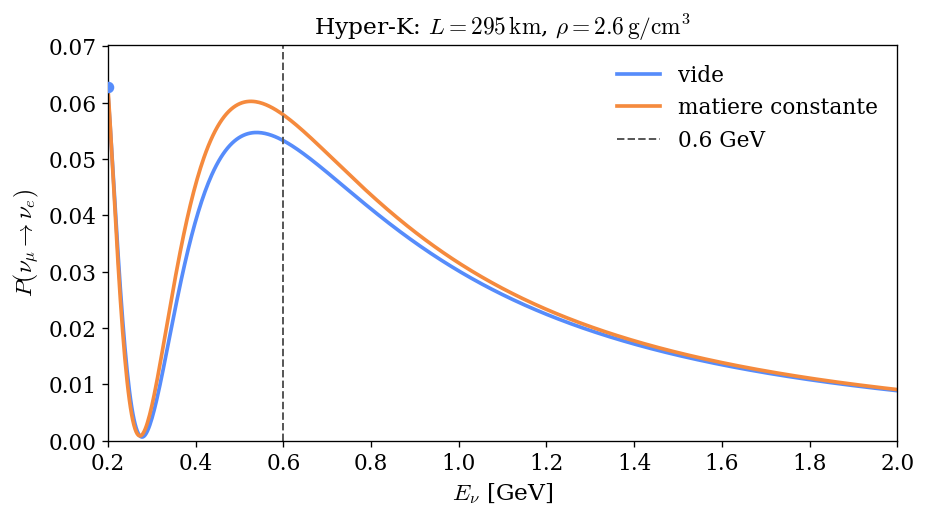

In [3]:
E = np.linspace(0.2, 2.0, 700)

P_vac_E = p_mue(osc_vac, L_HK_KM, E)
P_mat_E = p_mue(osc_mat, L_HK_KM, E)

idx_peak = np.argmax(P_mat_E)

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(E, P_vac_E, lw=2.2, label="vide")
ax.plot(E, P_mat_E, lw=2.2, label="matiere constante")
ax.axvline(E_HK_GEV, color="0.35", ls="--", lw=1.2, label="0.6 GeV")
ax.scatter(E[idx_peak], P_mat_E[idx_peak], s=35, zorder=3)
ax.set(
    xlabel=r"$E_\nu$ [GeV]",
    ylabel=r"$P(\nu_\mu \to \nu_e)$",
    title=rf"Hyper-K: $L = {L_HK_KM:.0f}\,\mathrm{{km}}$, $\rho = {RHO_CRUST_GCM3:.1f}\,\mathrm{{g/cm^3}}$",
    xlim=(E.min(), E.max()),
    ylim=(0, 1.12 * max(P_vac_E.max(), P_mat_E.max())),
)
ax.legend(frameon=False)
fig.tight_layout()

print(f"Au point Hyper-K E={E_HK_GEV:.2f} GeV, L={L_HK_KM:.0f} km:")
print(f"  P_vide    = {float(p_mue(osc_vac, L_HK_KM, E_HK_GEV)):.5f}")
print(f"  P_matiere = {float(p_mue(osc_mat, L_HK_KM, E_HK_GEV)):.5f}")
print(f"  delta     = {float(p_mue(osc_mat, L_HK_KM, E_HK_GEV) - p_mue(osc_vac, L_HK_KM, E_HK_GEV)):+.5f}")
print(f"Maximum matiere dans ce scan: E = {E[idx_peak]:.3f} GeV, P = {P_mat_E[idx_peak]:.5f}")

## Carte en distance et energie

Dans le vide, l'oscillation depend principalement du rapport $L/E$. La matiere ajoute une dependance supplementaire via le potentiel accumule pendant la propagation. Cette carte montre ou la correction de matiere est la plus visible autour de l'echelle Hyper-K.

Correction de matiere maximale sur la fenetre: 0.0345


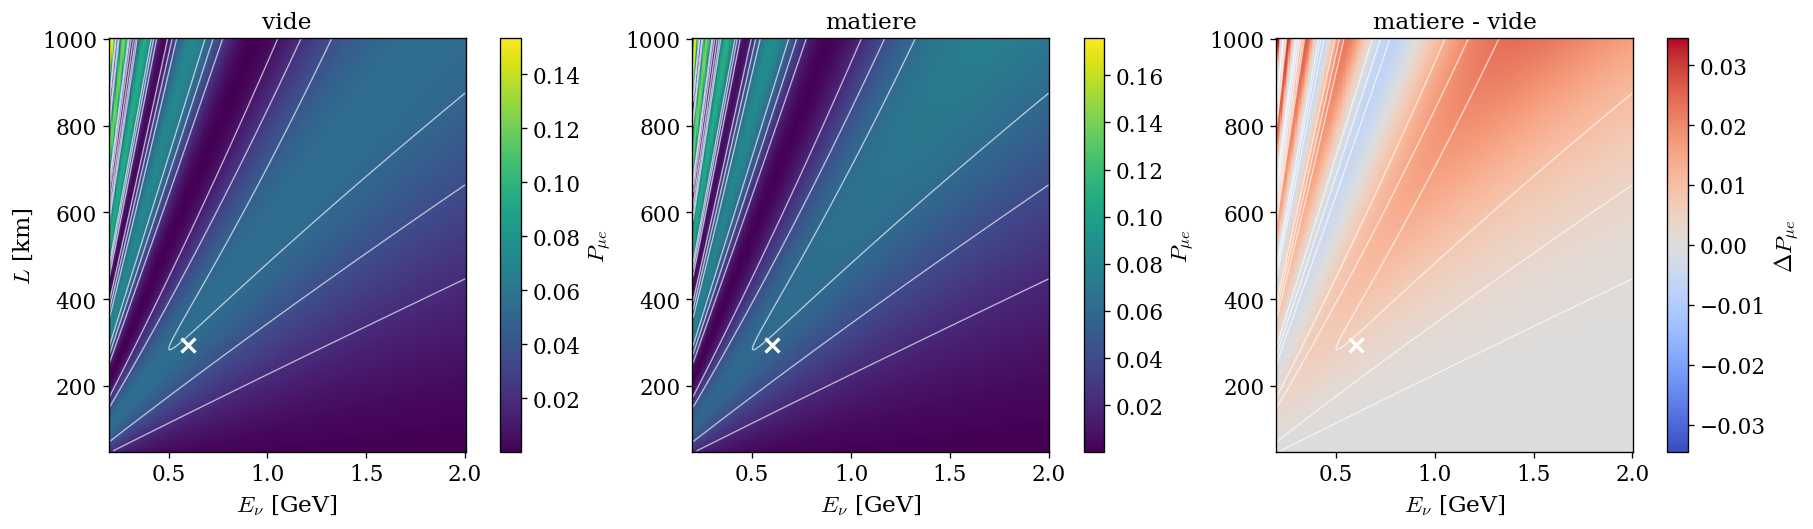

In [4]:
L_values = np.linspace(50.0, 1000.0, 240)
E_values = np.linspace(0.2, 2.0, 260)
EE, LL = np.meshgrid(E_values, L_values)

P_vac_grid = p_mue(osc_vac, LL.ravel(), EE.ravel()).reshape(LL.shape)
P_mat_grid = p_mue(osc_mat, LL.ravel(), EE.ravel()).reshape(LL.shape)
delta_grid = P_mat_grid - P_vac_grid

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), constrained_layout=True)

im0 = axes[0].pcolormesh(E_values, L_values, P_vac_grid, shading="auto", cmap="viridis")
axes[0].set(title="vide", xlabel=r"$E_\nu$ [GeV]", ylabel=r"$L$ [km]")
fig.colorbar(im0, ax=axes[0], label=r"$P_{\mu e}$")

im1 = axes[1].pcolormesh(E_values, L_values, P_mat_grid, shading="auto", cmap="viridis")
axes[1].set(title="matiere", xlabel=r"$E_\nu$ [GeV]")
fig.colorbar(im1, ax=axes[1], label=r"$P_{\mu e}$")

v = np.nanmax(np.abs(delta_grid))
im2 = axes[2].pcolormesh(E_values, L_values, delta_grid, shading="auto", cmap="coolwarm", vmin=-v, vmax=v)
axes[2].set(title="matiere - vide", xlabel=r"$E_\nu$ [GeV]")
fig.colorbar(im2, ax=axes[2], label=r"$\Delta P_{\mu e}$")

for ax in axes:
    ax.scatter([E_HK_GEV], [L_HK_KM], marker="x", s=70, c="white", lw=2)
    ax.contour(E_values, L_values, P_mat_grid, levels=[0.02, 0.04, 0.06], colors="white", linewidths=0.8, alpha=0.65)

print(f"Correction de matiere maximale sur la fenetre: {np.max(np.abs(delta_grid)):.4f}")

## Energie ou distance: quel effet domine ?

On compare les derivees logarithmiques numeriques. Une valeur de $|\partial P/\partial \ln E|$ plus grande signifie qu'une variation relative donnee de l'energie change davantage la probabilite qu'une variation relative identique de la baseline.

Attention: pres d'un extremum d'oscillation, les deux sensibilites peuvent devenir petites meme si la probabilite elle-meme est grande.

Sensibilites logarithmiques au point Hyper-K proche:
  E = 0.603 GeV, L = 296.4 km
  |dP/dlnE| = 0.0335
  |dP/dlnL| = 0.0381
  ratio E/L = 0.879
Ratio median sur la fenetre: 0.990


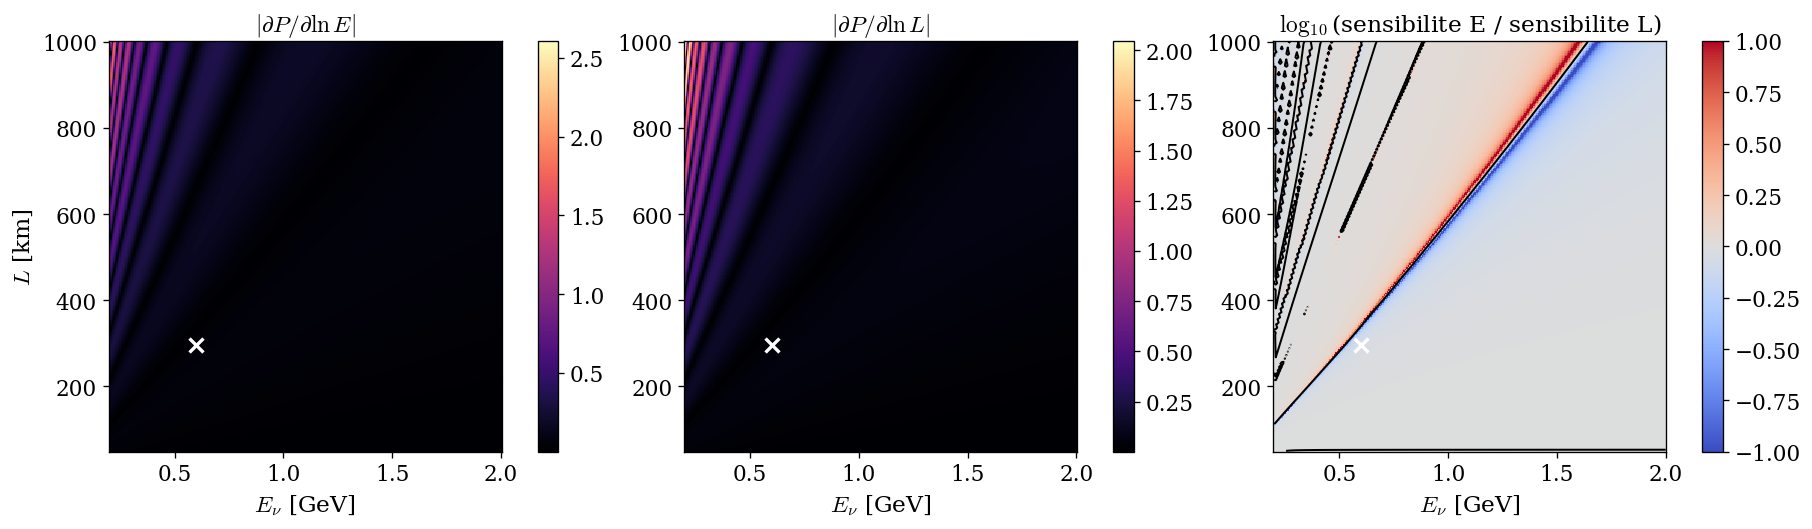

In [5]:
dP_dlogL, dP_dlogE = np.gradient(P_mat_grid, np.log(L_values), np.log(E_values), edge_order=2)
sens_L = np.abs(dP_dlogL)
sens_E = np.abs(dP_dlogE)
ratio_E_over_L = sens_E / np.maximum(sens_L, 1e-12)

iL = np.argmin(np.abs(L_values - L_HK_KM))
iE = np.argmin(np.abs(E_values - E_HK_GEV))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), constrained_layout=True)

im0 = axes[0].pcolormesh(E_values, L_values, sens_E, shading="auto", cmap="magma")
axes[0].set(title=r"$|\partial P/\partial\ln E|$", xlabel=r"$E_\nu$ [GeV]", ylabel=r"$L$ [km]")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(E_values, L_values, sens_L, shading="auto", cmap="magma")
axes[1].set(title=r"$|\partial P/\partial\ln L|$", xlabel=r"$E_\nu$ [GeV]")
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].pcolormesh(E_values, L_values, np.log10(ratio_E_over_L), shading="auto", cmap="coolwarm", vmin=-1, vmax=1)
axes[2].contour(E_values, L_values, ratio_E_over_L, levels=[1.0], colors="black", linewidths=1.2)
axes[2].set(title=r"$\log_{10}$(sensibilite E / sensibilite L)", xlabel=r"$E_\nu$ [GeV]")
fig.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.scatter([E_HK_GEV], [L_HK_KM], marker="x", s=70, c="white", lw=2)

local_sens_E = sens_E[iL, iE]
local_sens_L = sens_L[iL, iE]
median_ratio = np.nanmedian(ratio_E_over_L)

print("Sensibilites logarithmiques au point Hyper-K proche:")
print(f"  E = {E_values[iE]:.3f} GeV, L = {L_values[iL]:.1f} km")
print(f"  |dP/dlnE| = {local_sens_E:.4f}")
print(f"  |dP/dlnL| = {local_sens_L:.4f}")
print(f"  ratio E/L = {local_sens_E / max(local_sens_L, 1e-12):.3f}")
print(f"Ratio median sur la fenetre: {median_ratio:.3f}")

## Lecture physique rapide

- Dans le vide, la structure principale depend de $L/E$: changer $E$ ou $L$ a donc des effets tres similaires si on compare des variations relatives identiques, avec un signe oppose sur la phase.
- La matiere brise legerement cette symetrie car elle introduit une echelle supplementaire liee a la densite et a la longueur traversee.
- Pour Hyper-K, la baseline de $295\,\mathrm{km}$ reste assez courte: la correction de matiere est visible mais moderee. La conclusion attendue est donc que l'energie et la distance pilotent surtout la phase $L/E$, tandis que la matiere devient beaucoup plus discriminante quand la baseline augmente.